In [7]:
import os
# Version for filename
#ver = 'GRU'  # GRU or LSTM

date = "251128"
dl_folder = f"D:/Python_TK_3/datas/{date}_DL"

dl_number = "Vis_angle_multi_09"
#os.mkdir(f"{dl_folder}/model_{dl_number}")

In [8]:
# データのサンプリングレート
fs = 20  # サンプリング周波数
first_ex = 0
last_ex = 39
NumberOfDatas = last_ex - first_ex + 1        # number of experiments
start_stim = 20
stop_stim = 20.5
calc_start = 5
calc_end = 39
start_ave= 5
end_ave= 11
look_frame = 30   

In [11]:
import tqdm
import numpy as np

acc_list = []
val_acc_list = []
loss_list = []
val_loss_list = []
auc_list = []
val_auc_list = []
for n in tqdm.tqdm(range(5)):
    # 保存先ディレクトリを作成
    model_dir = os.path.join(os.path.join(dl_folder, f"model_{dl_number}"), f"model_{n}")

    acc     = np.load(os.path.join(model_dir, f"train_accuracy.npy"))
    val_acc = np.load(os.path.join(model_dir, f"valid_accuracy.npy"))
    acc_list.append(acc)
    val_acc_list.append(val_acc)

    loss     = np.load(os.path.join(model_dir, f"train_loss.npy"))
    val_loss = np.load(os.path.join(model_dir, f"valid_loss.npy"))
    loss_list.append(loss)
    val_loss_list.append(val_loss)

    auc     = np.load(os.path.join(model_dir, f"train_auc.npy"))
    val_auc = np.load(os.path.join(model_dir, f"valid_auc.npy"))
    auc_list.append(auc)
    val_auc_list.append(val_auc)

acc_list = np.array(acc_list)
val_acc_list = np.array(val_acc_list)
loss_list = np.array(loss_list)
val_loss_list = np.array(val_loss_list)
auc_list = np.array(auc_list)
val_auc_list = np.array(val_auc_list)

print(loss_list.shape, val_loss_list.shape, val_auc_list.shape)

100%|██████████| 5/5 [00:00<00:00, 221.22it/s]

(5,) (5,) (5,)


In [13]:
np.save((f"{dl_folder}/model_{dl_number}/{date}_{dl_number}_valid_accuracy_best.npy"), val_acc_list)
np.save((f"{dl_folder}/model_{dl_number}/{date}_{dl_number}_valid_loss_best.npy"), val_loss_list)
np.save((f"{dl_folder}/model_{dl_number}/{date}_{dl_number}_valid_auc_best.npy"), val_auc_list)

In [7]:
# 方法１：argmin + unravel_index
flat_index = val_loss_list.argmin()  # フラット（一次元）での最小値インデックス
row, col = np.unravel_index(flat_index, val_loss_list.shape)
print(row, col)  # → 1 2 （arr[1,2] が最小値 1）

3 5


In [8]:
mean_acc = np.mean(acc_list, axis=0)
sem_acc = np.std(acc_list, axis=0) / acc_list.shape[0]

mean_val_acc = np.mean(val_acc_list, axis=0)
sem_val_acc = np.std(val_acc_list, axis=0) / val_acc_list.shape[0]


mean_loss = np.mean(loss_list, axis=0)
sem_loss = np.std(loss_list, axis=0) / loss_list.shape[0]

mean_val_loss = np.mean(val_loss_list, axis=0)
sem_val_loss = np.std(val_loss_list, axis=0) / val_loss_list.shape[0]

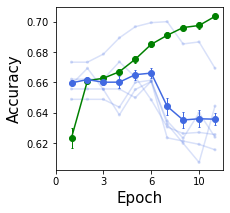

In [11]:
plt.figure(figsize=(3, 3))

plt.errorbar(np.arange(1, mean_acc.shape[0]+1), # 横軸
    mean_acc,   # 縦軸：平均値
    yerr=sem_acc,       # 縦方向のエラーバーに標準誤差を指定
    fmt='-o',       # プロットのマーカー＋線のスタイル。お好みで変更可
    capsize=1,      # エラーバーのキャップ（横線）の長さ
    elinewidth=1,   # エラーバー線の太さ
    markeredgewidth=1,
    color='green'
)

plt.errorbar(np.arange(1, mean_val_acc.shape[0]+1), # 横軸
    mean_val_acc,   # 縦軸：平均値
    yerr=sem_val_acc,       # 縦方向のエラーバーに標準誤差を指定
    fmt='-o',       # プロットのマーカー＋線のスタイル。お好みで変更可
    capsize=1,      # エラーバーのキャップ（横線）の長さ
    elinewidth=1,   # エラーバー線の太さ
    markeredgewidth=1,
    color='royalblue'
)

for row in val_acc_list:
    plt.scatter(np.arange(1, mean_val_acc.shape[0]+1), row,
               color='royalblue',
                alpha=0.2,   # 透明度
                s=10,        # マーカーサイズ
                marker='o',
                edgecolors='none')

for row in val_acc_list:
    plt.plot(np.arange(1, mean_val_acc.shape[0]+1), row,
                color='royalblue',
                alpha=0.2,   # 透明度
                #s=10,        # マーカーサイズ
                #marker='o',
                #edgecolors='none'
                )

#plt.title('Cumulative Explained Variance')
#plt.xlabel('Components #')
plt.xlabel("Epoch", fontsize=15)
plt.ylabel('Accuracy', fontsize=15)
#plt.ylim(0.85, 1.01)
ticks = np.arange(0, 11, 3)
labels = np.linspace(0, 10, len(ticks)).astype(int)
plt.xticks(ticks, labels)
plt.xlim(0, 10.5)

plt.show()

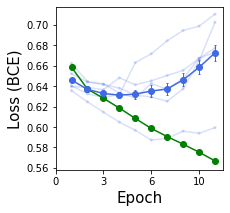

In [14]:
plt.figure(figsize=(3, 3))

plt.errorbar(np.arange(1, mean_loss.shape[0]+1), # 横軸
    mean_loss,   # 縦軸：平均値
    yerr=sem_loss,       # 縦方向のエラーバーに標準誤差を指定
    fmt='-o',       # プロットのマーカー＋線のスタイル。お好みで変更可
    capsize=1,      # エラーバーのキャップ（横線）の長さ
    elinewidth=1,   # エラーバー線の太さ
    markeredgewidth=1,
    color='green'
)

plt.errorbar(np.arange(1, mean_val_loss.shape[0]+1), # 横軸
    mean_val_loss,   # 縦軸：平均値
    yerr=sem_val_loss,       # 縦方向のエラーバーに標準誤差を指定
    fmt='-o',       # プロットのマーカー＋線のスタイル。お好みで変更可
    capsize=1,      # エラーバーのキャップ（横線）の長さ
    elinewidth=1,   # エラーバー線の太さ
    markeredgewidth=1,
    color='royalblue'
)

for row in val_loss_list:
    plt.scatter(np.arange(1, mean_val_loss.shape[0]+1), row,
                color='royalblue',
                alpha=0.2,   # 透明度
                s=10,        # マーカーサイズ
                marker='o',
                edgecolors='none')

for row in val_loss_list:
    plt.plot(np.arange(1, mean_val_loss.shape[0]+1), row,
                color='royalblue',
                alpha=0.2,   # 透明度
                #s=10,        # マーカーサイズ
                #marker='o',
                #edgecolors='none'
                )


#plt.title('Cumulative Explained Variance')
#plt.xlabel('Components #')
plt.xlabel("Epoch", fontsize=15)
plt.ylabel('Loss (BCE)', fontsize=15)
#plt.ylim(0.85, 1.01)
ticks = np.arange(0, 11, 3)
labels = np.linspace(0, 10, len(ticks)).astype(int)
plt.xticks(ticks, labels)
plt.xlim(0, 10.5)

plt.show()

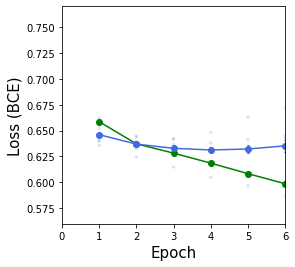

In [11]:
plt.figure(figsize=(4, 4))

plt.errorbar(np.arange(1, mean_loss.shape[0]+1), # 横軸
    mean_loss,   # 縦軸：平均値
    yerr=sem_loss,       # 縦方向のエラーバーに標準誤差を指定
    fmt='-o',       # プロットのマーカー＋線のスタイル。お好みで変更可
    capsize=1,      # エラーバーのキャップ（横線）の長さ
    elinewidth=1,   # エラーバー線の太さ
    markeredgewidth=1,
    color='green'
)

plt.errorbar(np.arange(1, mean_val_loss.shape[0]+1), # 横軸
    mean_val_loss,   # 縦軸：平均値
    yerr=sem_val_loss,       # 縦方向のエラーバーに標準誤差を指定
    fmt='-o',       # プロットのマーカー＋線のスタイル。お好みで変更可
    capsize=1,      # エラーバーのキャップ（横線）の長さ
    elinewidth=1,   # エラーバー線の太さ
    markeredgewidth=1,
    color='royalblue'
)

for row in val_loss_list:
    plt.scatter(np.arange(1, mean_val_loss.shape[0]+1), row,
                color='royalblue',
                alpha=0.2,   # 透明度
                s=10,        # マーカーサイズ
                marker='o',
                edgecolors='none')



#plt.title('Cumulative Explained Variance')
#plt.xlabel('Components #')
plt.xlabel("Epoch", fontsize=15)
plt.ylabel('Loss (BCE)', fontsize=15)
plt.xlim(0, 6)
plt.ylim(0.56, 0.77)

plt.show()

In [15]:
import shap
import numpy


def calc_shap(input_data, data_pred, model):
    #num_data = 1*100  # background sample number (about 1/20)
    #num_data = int(input_data.shape[0]/20)  # background sample number (about 1/20)
    #data_idx = numpy.random.choice(range(input_data.shape[0]), num_data, replace=False)
    data_idx = list(range(0, input_data.shape[0], 20))
    base = data_pred[data_idx].mean()
    explainer = shap.DeepExplainer(model, input_data[data_idx])
    shap_val = numpy.zeros(input_data.shape)
    
    # calculate shap value of all data
    BATCH_SIZE = 99  # 割り切れない数
    for idx in range(input_data.shape[0] // BATCH_SIZE + 1):
        if idx != input_data.shape[0] // BATCH_SIZE:
            bs = BATCH_SIZE
        else:
            bs = input_data.shape[0] % BATCH_SIZE
        input_shap = input_data[idx * BATCH_SIZE:(idx) * BATCH_SIZE + bs]
        shap_val[idx * BATCH_SIZE:(idx) * BATCH_SIZE + bs] = numpy.array(explainer.shap_values(input_shap))
    
    return shap_val, base

In [16]:
def calc_roc(y_pred, y_test):
    fpr, tpr, thresholds = roc_curve(y_test, y_pred, pos_label=1)
    AUC = roc_auc_score(y_test, y_pred)
    opt_thr = thresholds[numpy.argmax(tpr - fpr)]

    return fpr, tpr, AUC, opt_thr

In [17]:
#epoch = 30

#test_data = 8
ex_frames = 50

shap_vals = []
bases = []
for n in tqdm.tqdm(range(5)):
    # 保存先ディレクトリを作成
    model_dir = os.path.join(os.path.join(dl_folder, f"model_{dl_number}"), f"model_{n}")


    epoch = val_loss_list[n].argmin() + 1
    if epoch > 9:
        # ファイル名にエポック番号を含めるフォーマットに変更
        model_file_path = os.path.join(
            model_dir,
            f"{date}_{dl_number}_ver{ver}_epoch{epoch}.h5"
        )

    if epoch < 10:
        # ファイル名にエポック番号を含めるフォーマットに変更
        model_file_path = os.path.join(
            model_dir,
            f"{date}_{dl_number}_ver{ver}_epoch0{epoch}.h5"
        )        

    model = load_model(model_file_path)

    #input_test = np.load(f"{model_dir}/{date}_{dl_number}_test_features.npy")
    #testY = np.load(f"{model_dir}/{date}_{dl_number}_test_targets.npy")


    input_train = np.load(f"{model_dir}/{date}_{dl_number}_train_features.npy")
    trainY = np.load(f"{model_dir}/{date}_{dl_number}_train_targets.npy")
    input_valid = np.load(f"{model_dir}/{date}_{dl_number}_valid_features.npy")
    validY = np.load(f"{model_dir}/{date}_{dl_number}_valid_targets.npy")

    train_pred = model.predict(input_train)
    fpr_tr, tpr_tr, AUC_tr, opt_thr_tr = calc_roc(train_pred, trainY)
    np.save((f"{model_dir}/{date}_{dl_number}_train_fpr.npy"), fpr_tr)
    np.save((f"{model_dir}/{date}_{dl_number}_train_tpr.npy"), tpr_tr)
    np.save((f"{model_dir}/{date}_{dl_number}_train_auc.npy"), AUC_tr)
    np.save((f"{model_dir}/{date}_{dl_number}_train_threshold.npy"), opt_thr_tr)

    valid_pred = model.predict(input_valid)
    fpr_va, tpr_va, AUC_va, opt_thr_va = calc_roc(valid_pred, validY)
    np.save((f"{model_dir}/{date}_{dl_number}_valid_fpr.npy"), fpr_va)
    np.save((f"{model_dir}/{date}_{dl_number}_valid_tpr.npy"), tpr_va)
    np.save((f"{model_dir}/{date}_{dl_number}_valid_auc.npy"), AUC_va)
    np.save((f"{model_dir}/{date}_{dl_number}_valid_threshold.npy"), opt_thr_va)

    #test_pred = model.predict(input_test)
    #fpr_te, tpr_te, AUC_te, opt_thr_te = calc_roc(test_pred, testY)
    #np.save((f"{model_dir}/{date}_{dl_number}_test_fpr.npy"), fpr_te)
    #np.save((f"{model_dir}/{date}_{dl_number}_test_tpr.npy"), tpr_te)
    #np.save((f"{model_dir}/{date}_{dl_number}_test_auc.npy"), AUC_te)
    #np.save((f"{model_dir}/{date}_{dl_number}_test_threshold.npy"), opt_thr_te)


    classified_valid_pred = []
    for f in range(valid_pred.shape[0]):
        if valid_pred[f, 0] > opt_thr_va:
            classified_valid_pred.append(1)
        else:
            classified_valid_pred.append(0)
    classified_valid_pred = np.array(classified_valid_pred)

    #test_pred = model.predict(input_test)
    shap_val, base = calc_shap(input_valid, valid_pred, model)

    np.save((f"{model_dir}/{date}_{dl_number}_shap_val.npy"), np.array(shap_val))
    np.save((f"{model_dir}/{date}_{dl_number}_shap_base.npy"), base)

    shap_vals.append(np.array(shap_val))
    bases.append(base)

    
    first_positives = []
    for ex in range(int(input_valid.shape[0]/ex_frames)):
        #if np.all(classified_valid_pred[ex*ex_frames+20:(ex+1)*ex_frames] == 1):
        #    first_positives.append(ex*ex_frames+20)
        for f in range(20, ex_frames):
            if classified_valid_pred[ex*ex_frames+f] == 1 and np.all(classified_valid_pred[ex*ex_frames+20:ex*ex_frames+f] == 0):
                first_positives.append(ex*ex_frames+f)
    first_positives = np.array(first_positives)
    np.save((f"{model_dir}/{date}_{dl_number}_valid_1st_positive_frames.npy"), first_positives)
                

print(shap_vals[0].shape)
print(first_positives)

  0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 5/5 [15:06<00:00, 181.26s/it]

(1350, 31, 23)
[  20   70  120  170  220  270  320  375  470  529  596  620  720  770
  849  870  920  972 1028 1070 1131 1170 1237 1270 1320 1370 1420 1470]


In [14]:
#epoch = 30

#test_data = 8
ex_frames = 50

#shap_vals = []
#bases = []
best_acc, best_loss = [], []
for n in tqdm.tqdm(range(5)):
    # 保存先ディレクトリを作成
    model_dir = os.path.join(os.path.join(dl_folder, f"model_{dl_number}"), f"model_{n}")


    epoch = val_loss_list[n].argmin() + 1
    if epoch > 9:
        # ファイル名にエポック番号を含めるフォーマットに変更
        model_file_path = os.path.join(
            model_dir,
            f"{date}_{dl_number}_ver{ver}_epoch{epoch}.h5"
        )

    if epoch < 10:
        # ファイル名にエポック番号を含めるフォーマットに変更
        model_file_path = os.path.join(
            model_dir,
            f"{date}_{dl_number}_ver{ver}_epoch0{epoch}.h5"
        )        

    model = load_model(model_file_path)

    #input_test = np.load(f"{model_dir}/{date}_{dl_number}_test_features.npy")
    #testY = np.load(f"{model_dir}/{date}_{dl_number}_test_targets.npy")


    input_train = np.load(f"{model_dir}/{date}_{dl_number}_train_features.npy")
    trainY = np.load(f"{model_dir}/{date}_{dl_number}_train_targets.npy")
    input_valid = np.load(f"{model_dir}/{date}_{dl_number}_valid_features.npy")
    validY = np.load(f"{model_dir}/{date}_{dl_number}_valid_targets.npy")

    train_pred = model.predict(input_train)
    fpr_tr, tpr_tr, AUC_tr, opt_thr_tr = calc_roc(train_pred, trainY)
    np.save((f"{model_dir}/{date}_{dl_number}_train_fpr.npy"), fpr_tr)
    np.save((f"{model_dir}/{date}_{dl_number}_train_tpr.npy"), tpr_tr)
    np.save((f"{model_dir}/{date}_{dl_number}_train_auc.npy"), AUC_tr)
    np.save((f"{model_dir}/{date}_{dl_number}_train_threshold.npy"), opt_thr_tr)

    valid_pred = model.predict(input_valid)
    fpr_va, tpr_va, AUC_va, opt_thr_va = calc_roc(valid_pred, validY)
    np.save((f"{model_dir}/{date}_{dl_number}_valid_fpr.npy"), fpr_va)
    np.save((f"{model_dir}/{date}_{dl_number}_valid_tpr.npy"), tpr_va)
    np.save((f"{model_dir}/{date}_{dl_number}_valid_auc.npy"), AUC_va)
    np.save((f"{model_dir}/{date}_{dl_number}_valid_threshold.npy"), opt_thr_va)

    #np.save((f"{model_dir}/{date}_{dl_number}_valid_accuracy_best.npy"), val_acc_list[n][epoch-1])
    #np.save((f"{model_dir}/{date}_{dl_number}_valid_loss_best.npy"), val_loss_list[n][epoch-1])

    best_acc.append(val_acc_list[n][epoch-1])
    best_loss.append(val_loss_list[n][epoch-1])

    #test_pred = model.predict(input_test)
    #fpr_te, tpr_te, AUC_te, opt_thr_te = calc_roc(test_pred, testY)
    #np.save((f"{model_dir}/{date}_{dl_number}_test_fpr.npy"), fpr_te)
    #np.save((f"{model_dir}/{date}_{dl_number}_test_tpr.npy"), tpr_te)
    #np.save((f"{model_dir}/{date}_{dl_number}_test_auc.npy"), AUC_te)
    #np.save((f"{model_dir}/{date}_{dl_number}_test_threshold.npy"), opt_thr_te)


    classified_valid_pred = []
    for f in range(valid_pred.shape[0]):
        if valid_pred[f, 0] > opt_thr_va:
            classified_valid_pred.append(1)
        else:
            classified_valid_pred.append(0)
    classified_valid_pred = np.array(classified_valid_pred)

    #test_pred = model.predict(input_test)
    #shap_val, base = calc_shap(input_valid, valid_pred, model)

    #np.save((f"{model_dir}/{date}_{dl_number}_shap_val.npy"), np.array(shap_val))
    #np.save((f"{model_dir}/{date}_{dl_number}_shap_base.npy"), base)

    #shap_vals.append(np.array(shap_val))
    #bases.append(base)

    
    first_positives = []
    for ex in range(int(input_valid.shape[0]/ex_frames)):
        #if np.all(classified_valid_pred[ex*ex_frames+20:(ex+1)*ex_frames] == 1):
        #    first_positives.append(ex*ex_frames+20)
        for f in range(20, ex_frames):
            if classified_valid_pred[ex*ex_frames+f] == 1 and np.all(classified_valid_pred[ex*ex_frames+20:ex*ex_frames+f] == 0):
                first_positives.append(ex*ex_frames+f)
    first_positives = np.array(first_positives)
    np.save((f"{model_dir}/{date}_{dl_number}_valid_1st_positive_frames.npy"), first_positives)
                
best_acc, best_loss = np.array(best_acc), np.array(best_loss)

#print(shap_vals[0].shape)
print(first_positives)
print(best_acc.shape, best_loss.shape)

100%|██████████| 5/5 [00:29<00:00,  5.82s/it]

[  20   70  120  170  220  270  320  375  470  529  596  620  720  770
  849  870  920  972 1028 1070 1131 1170 1237 1270 1320 1370 1420 1470]
(5,) (5,)


In [15]:
np.save((f"{dl_folder}/model_{dl_number}/{date}_{dl_number}_valid_accuracy_best.npy"), best_acc)
np.save((f"{dl_folder}/model_{dl_number}/{date}_{dl_number}_valid_loss_best.npy"), best_loss)

In [13]:
#mean_shap = []
#for n in tqdm.tqdm(range(20)):
 #   mean = np.mean(np.abs(shap_vals[n]), axis=0)
  #  mean_shap.append(mean)

#mean_shap = np.array(mean_shap)
#print(mean_shap.shape)

In [15]:
#np.save((f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_ShapValue_{mean_shap.shape[0]}models.npy"), mean_shap)